# 1. Select a Trained Classifier — Best_Model

We use `Best_Model` trained on the full train+val set, saved as `baseline_best.pth` (accuracy 97.95%, F1 97.09% on test set).

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from sklearn.metrics import f1_score, accuracy_score
from pytorch_grad_cam import ScoreCAM

# add the directory of our general py functions
sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu
from pipeline_helper import MyPreprocess
from model_helper import BestModel
from pipeline_helper import MyToTensor
from img_helper import show_images

In [2]:
device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Prediction shape: (5, 1)  — running on device: cuda


In [3]:
DATA_DIR = "../../data/1_source/"

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyPreprocess()
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Test samples: 146
Classes: ['0', '1']


In [4]:
MODEL_PATH = "../2_basemodel/baseline_best.pth"
model = BestModel.load(MODEL_PATH, device)
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")

Test samples: 146
Accuracy: 0.9795
F1 Score: 0.9709


In [6]:
# setting the global colors and labels used for analysis
CLASS_VALUES = [0, 1]
CLASS_NAMES = ["Healthy", "OA"]
CLASS_COLORS = ["blue", "red"]

# 2. Implement Score-CAM

We use the **[pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam)** library with **Score-CAM** instead of GradCAM.

**Why not GradCAM?** `Best_Model` contains `AdaptiveAvgPool2d(1)` after the last conv block. During backpropagation, this layer distributes the incoming gradient equally to every spatial position — making the gradient spatially uniform before it reaches the target layer. GradCAM weights are then the same everywhere, producing diffuse heatmaps that reflect activation magnitude rather than spatial relevance.

**Score-CAM** avoids this entirely — it uses no gradients. Instead, for each channel k of the target layer it:
1. Upsamples activation map k to input size and uses it as a spatial mask.
2. Forward-passes the masked image through the full model.
3. Assigns weight α_k = confidence change caused by that mask.
4. Returns ReLU of the weighted sum of activation maps.

`AdaptiveAvgPool2d` is irrelevant to Score-CAM since there is no backward pass.

We target `model.gradcam_layer` — the ReLU after the last conv block, which produces 32×32 feature maps (256 channels → 256 forward passes per image).

In [7]:
display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyToTensor()
)

grad_cam = ScoreCAM(model=model, target_layers=[model.gradcam_layer])
print("ScoreCAM target: model.gradcam_layer (last conv ReLU, 32×32, 256 channels)")

ScoreCAM target: model.gradcam_layer (last conv ReLU, 32×32, 256 channels)


In [8]:
# printing functions
def overlay_heatmap(img_tensor, cam, alpha=0.5) -> np.ndarray:
    """
    Blend a Grad-CAM heatmap onto a grayscale image tensor.
    img_tensor : (1, H, W) float tensor in [0, 1]
    cam        : (H, W) numpy array in [0, 1]
    Returns    : (H, W, 3) numpy array ready for imshow
    """
    img_np = img_tensor.squeeze().numpy()
    H, W = img_np.shape

    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_up = F.interpolate(cam_t, size=(H, W), mode="bilinear", align_corners=False)
    cam_up = cam_up.squeeze().numpy()

    heatmap = plt.colormaps["jet"](cam_up)[:, :, :3]
    img_rgb = np.stack([img_np] * 3, axis=-1)
    return np.clip(alpha * heatmap + (1 - alpha) * img_rgb, 0, 1)


def show_gradcam(
    indices,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    class_names,
    device,
    title="",
    n=5,
) -> None:
    """
    Plot Grad-CAM results: original image (top) + heatmap overlay (bottom) per column.
    Delegates grid layout and titling to show_images.
    """
    indices = indices[:n]
    overlays = []
    for idx in indices:
        img_display, _ = display_dataset[idx]
        img_tensor, _ = test_dataset[idx]
        grayscale = grad_cam(
            input_tensor=img_tensor.unsqueeze(0).to(device), targets=None
        )
        overlays.append(overlay_heatmap(img_display, grayscale[0]))

    show_images(
        indices,
        display_dataset,
        all_labels=all_labels,
        all_preds=all_preds,
        all_probs=all_probs,
        class_names=class_names,
        title=title,
        overlays=overlays,
    )

# 3. Qualitative Analysis

In [9]:
correct_healthy = np.where(
    (all_labels == CLASS_VALUES[0]) & (all_preds == CLASS_VALUES[0])
)[0]
correct_oa = np.where((all_labels == CLASS_VALUES[1]) & (all_preds == CLASS_VALUES[1]))[
    0
]
misclassified = np.where(all_labels != all_preds)[0]

print(f"Correctly classified {CLASS_NAMES[0]}: {len(correct_healthy)}")
print(f"Correctly classified {CLASS_NAMES[1]}     : {len(correct_oa)}")
print(f"Misclassified              : {len(misclassified)}")

Correctly classified Healthy: 93
Correctly classified OA     : 50
Misclassified              : 3


100%|██████████| 16/16 [00:00<00:00, 99.21it/s] 


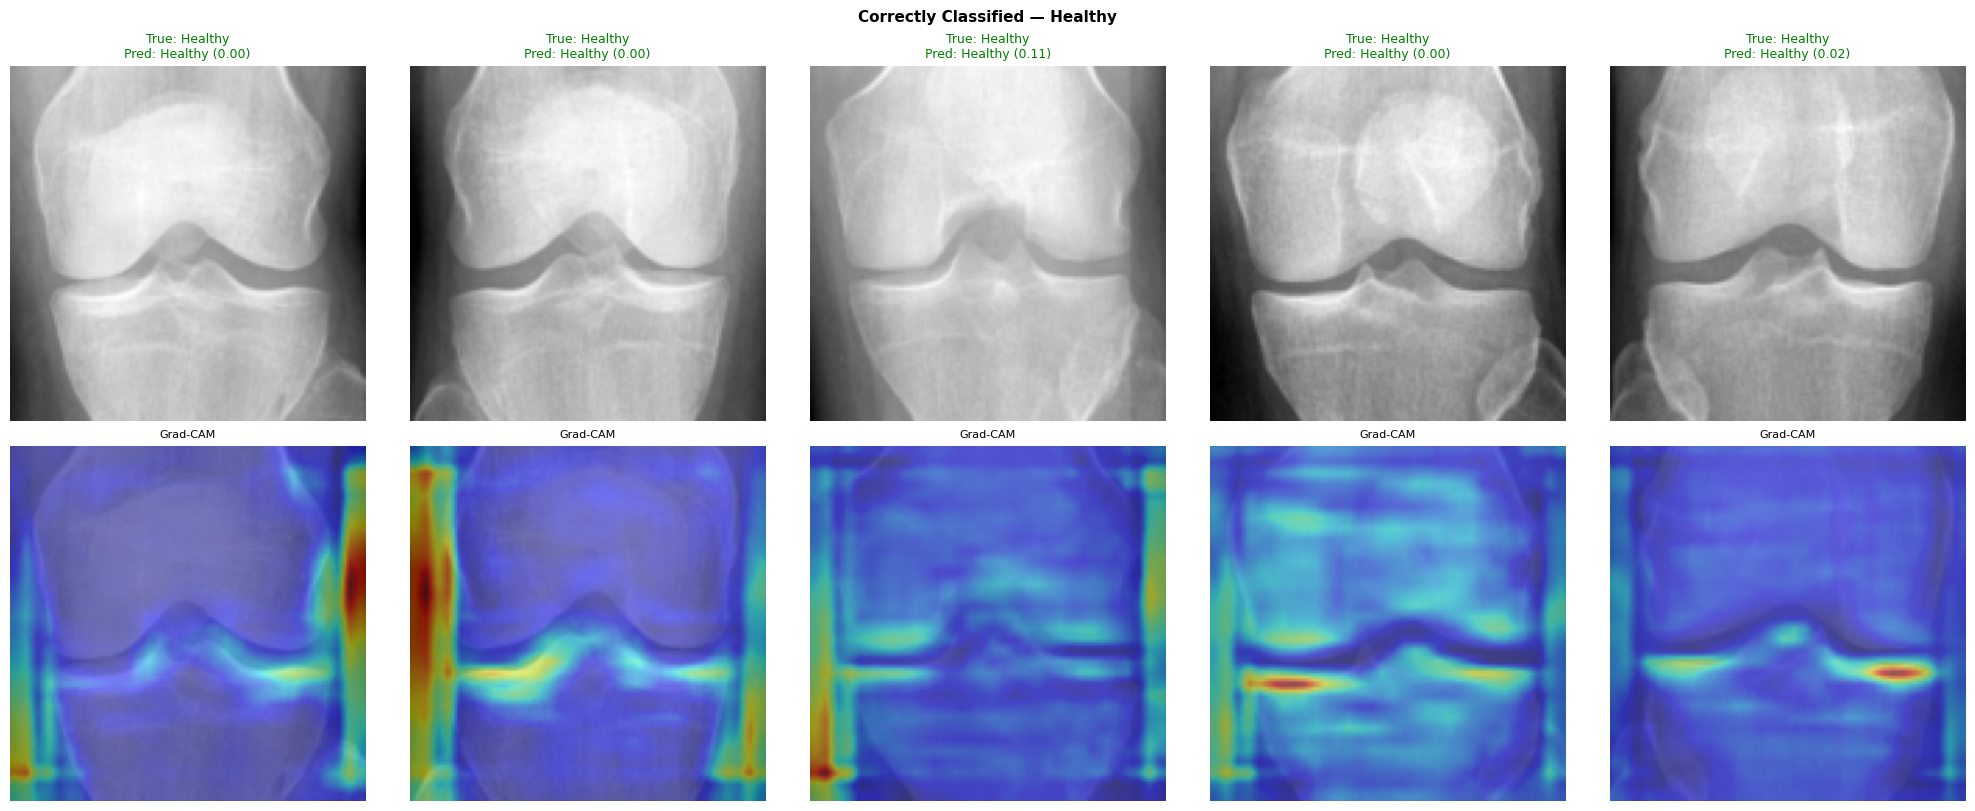

In [10]:
show_gradcam(
    correct_healthy,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title=f"Correctly Classified — {CLASS_NAMES[0]}",
)

100%|██████████| 16/16 [00:00<00:00, 98.78it/s]


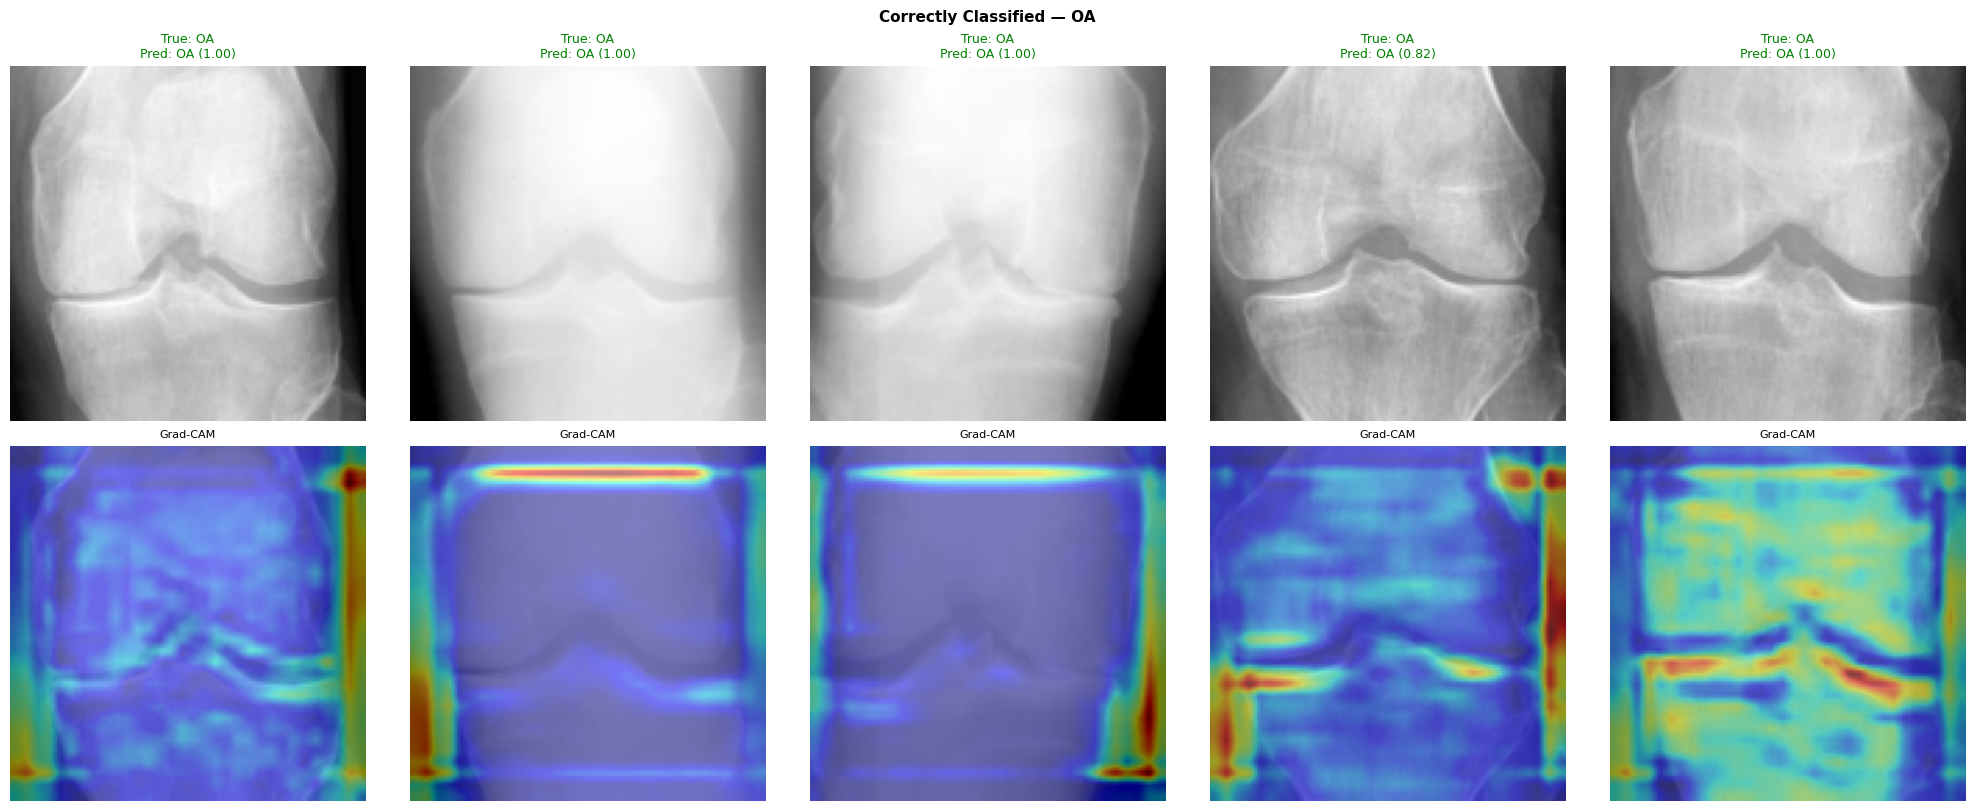

In [11]:
show_gradcam(
    correct_oa,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title=f"Correctly Classified — {CLASS_NAMES[1]}",
)

100%|██████████| 16/16 [00:00<00:00, 98.71it/s]


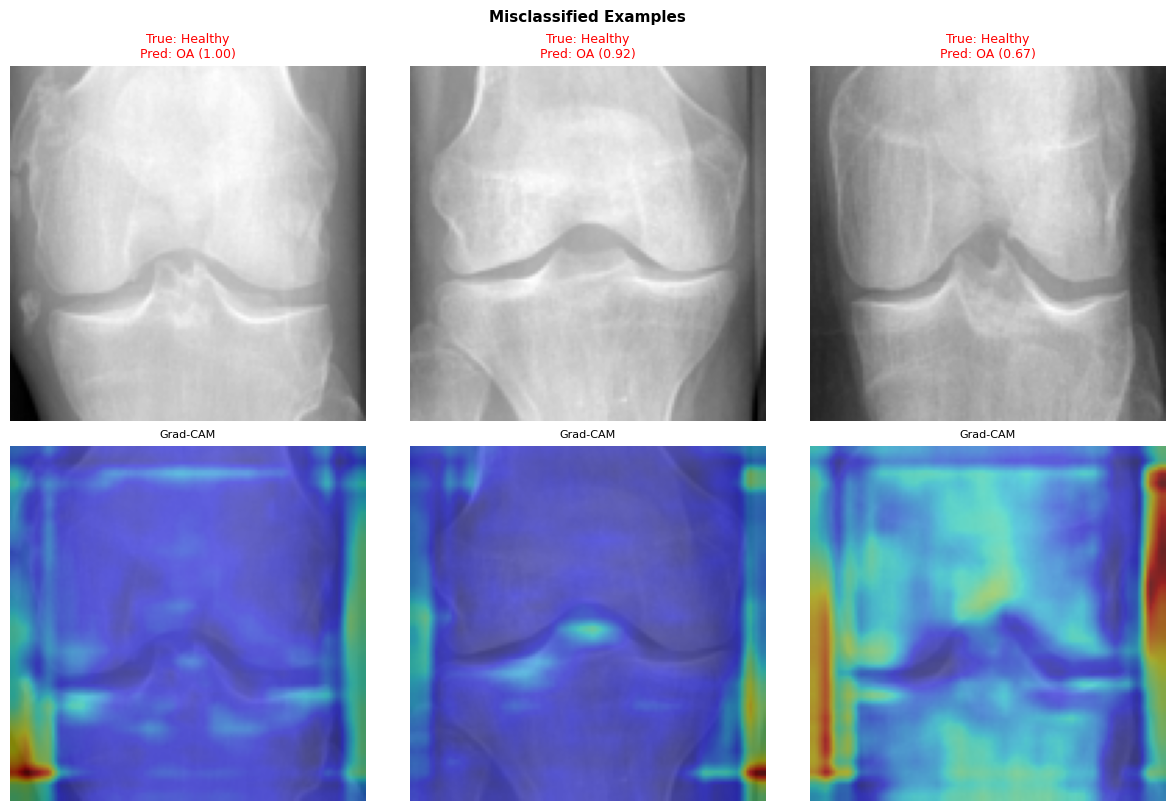

In [12]:
show_gradcam(
    misclassified,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Misclassified Examples",
    n=50,
)

# 4. Clinical Interpretation

In knee OA X-rays the clinically relevant region is the **knee joint space** — the gap between femur and tibia, visible as a bright horizontal band in the vertical centre of the image.

We quantify clinical relevance with two spatial statistics computed on each Grad-CAM heatmap:

---

### Central-band activation fraction
The image is split into three equal horizontal bands (top / middle / bottom, each 43 rows tall at 128 px):

```
row   0 ┌──────────────┐
         │   top third  │  (irrelevant — femur shaft, soft tissue)
row  43 ├──────────────┤
         │ MIDDLE THIRD │  ← joint space lives here
row  85 ├──────────────┤
         │ bottom third │  (irrelevant — tibia shaft)
row 127 └──────────────┘
```

The metric is:

> **central-band fraction = (sum of Grad-CAM activation in rows 43–85) / (total activation)**

Interpretation:
- **= 1/3 ≈ 0.33** → activation is spread uniformly — the model looks everywhere equally (random baseline)
- **> 1/3** → the model attends *more* to the joint space than chance; clinically plausible
- **< 1/3** → the model is actively avoiding the joint space; activations are in the periphery

---

### Vertical centre of mass (CoM)
The activation-weighted average row position, rescaled so **0 = bottom of image, 1 = top, 0.5 = centre**.

A CoM near 0.5 means the "centre of gravity" of the heatmap sits at the middle of the image — again consistent with joint-space focus.

100%|██████████| 16/16 [00:00<00:00, 98.73it/s]


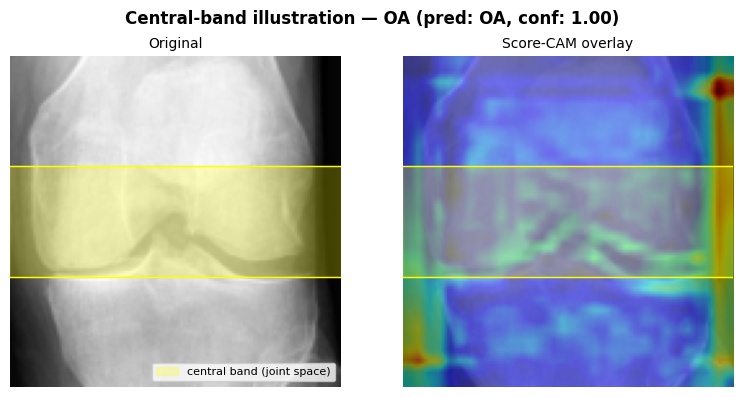

In [13]:
# Illustrate where the central band sits on a real example image + its Score-CAM heatmap
example_idx = correct_oa[0]
img_display, _ = display_dataset[example_idx]
img_tensor, _ = test_dataset[example_idx]

grayscale = grad_cam(input_tensor=img_tensor.unsqueeze(0).to(device), targets=None)
cam_ex = grayscale[0]

overlay = overlay_heatmap(img_display, cam_ex)

H = img_display.shape[-1]
r1, r2 = H // 3, 2 * H // 3
band_color, band_alpha = "yellow", 0.25

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (im, label) in zip(
    axes, [(img_display.squeeze().numpy(), "Original"), (overlay, "Score-CAM overlay")]
):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.axhspan(
        r1, r2, color=band_color, alpha=band_alpha, label="central band (joint space)"
    )
    ax.axhline(r1, color=band_color, linewidth=1)
    ax.axhline(r2, color=band_color, linewidth=1)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(
    f"Central-band illustration — {CLASS_NAMES[int(all_labels[example_idx])]} "
    f"(pred: {CLASS_NAMES[int(all_preds[example_idx])]}, conf: {all_probs[example_idx]:.2f})",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [14]:
# Run Score-CAM on every test image and collect spatial statistics
cam_stats = []

for idx in range(len(test_dataset)):
    img_tensor, _ = test_dataset[idx]
    img_input = img_tensor.unsqueeze(0).to(device)

    grayscale = grad_cam(input_tensor=img_input, targets=None)
    cam = grayscale[0]  # (H, W), normalised to [0, 1]

    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_up = F.interpolate(cam_t, size=(128, 128), mode="bilinear", align_corners=False)
    cam_up = cam_up.squeeze().numpy()

    H, W = cam_up.shape
    total = cam_up.sum() + 1e-8

    r1, r2 = H // 3, 2 * H // 3  # rows 43–85, which is the middle third of the image
    center_frac = cam_up[r1:r2, :].sum() / total

    # vertical CoM: 0 = bottom, 1 = top, 0.5 = centre
    y_idx = 1 - np.arange(H).reshape(-1, 1) / (H - 1)
    com_y = (cam_up * y_idx).sum() / total

    cam_stats.append(
        {
            "idx": idx,
            "center_frac": float(center_frac),
            "com_y": float(com_y),
            "label": int(all_labels[idx]),
            "pred": int(all_preds[idx]),
        }
    )

center_frac_arr = np.array([s["center_frac"] for s in cam_stats])
com_y_arr = np.array([s["com_y"] for s in cam_stats])
class_masks = [all_labels == cls for cls in CLASS_VALUES]

for mask, name in zip(class_masks, CLASS_NAMES):
    print(f"Mean central-band fraction  — {name}: {center_frac_arr[mask].mean():.3f}")
    print(f"Mean vertical CoM (0.5=mid) — {name}: {com_y_arr[mask].mean():.3f}")

100%|██████████| 16/16 [00:00<00:00, 99.42it/s]

Mean central-band fraction  — Healthy: 0.367
Mean vertical CoM (0.5=mid) — Healthy: 0.473
Mean central-band fraction  — OA: 0.314
Mean vertical CoM (0.5=mid) — OA: 0.479


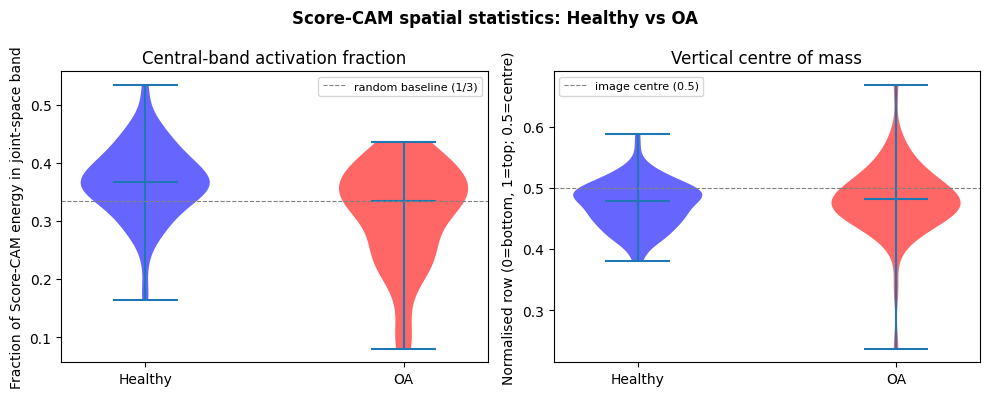

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

datasets_info = [
    (
        center_frac_arr,
        "Central-band activation fraction",
        "Fraction of Score-CAM energy in joint-space band",
        1 / 3,
        "random baseline (1/3)",
    ),
    (
        com_y_arr,
        "Vertical centre of mass",
        "Normalised row (0=bottom, 1=top; 0.5=centre)",
        0.5,
        "image centre (0.5)",
    ),
]

for ax, (values, title, ylabel, ref, ref_label) in zip(axes, datasets_info):
    data = [values[mask] for mask in class_masks]
    parts = ax.violinplot(data, positions=CLASS_VALUES, showmedians=True)

    for pc, color in zip(parts["bodies"], CLASS_COLORS):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    ax.set_xticks(CLASS_VALUES)
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(ref, color="gray", linestyle="--", linewidth=0.8, label=ref_label)
    ax.legend(fontsize=8)

plt.suptitle(
    f"Score-CAM spatial statistics: {' vs '.join(CLASS_NAMES)}", fontweight="bold"
)
plt.tight_layout()
plt.show()

Score-CAM removes the gradient artifact seen in GradCAM2 and reveals the true spatial attribution:

- **Healthy: 0.367** — marginally above the random baseline (0.333). No clinically meaningful joint-space preference.
- **OA: 0.314** — slightly *below* chance. The model's OA decision is driven by non-joint-space regions.
- **CoM Healthy: 0.473 / OA: 0.479** — both near 0.5 (image centre), with negligible class difference (0.006).
- **Low-focus outliers: [0.079, 0.098, 0.104, 0.164, 0.168, 0.177]** — a subset of images where the model's entire decision is driven by the image periphery.

Neither class shows clinically meaningful joint-space focus. The near-random values confirm what the latent space analysis suggested: the model uses one dominant global image property distributed across the full image, with no spatial preference for the anatomically relevant region.

### Discussion

| Metric | Healthy | OA | Random baseline | Interpretation |
|---|---|---|---|---|
| Central-band fraction | 0.367 | 0.314 | 0.333 | Neither class exceeds chance by a meaningful margin |
| Vertical CoM | 0.473 | 0.479 | 0.500 | Both classes near centre; Δ = 0.006 (negligible) |

**Score-CAM confirms the latent space finding.** Both analyses converge on the same conclusion: `Best_Model` does not attend to the anatomically relevant knee joint space. The latent space collapses to a near-1D axis (PC1 = 91.1%, cumulative 99.4%), indicating the model learned one dominant global image property. The Score-CAM spatial statistics — both classes within ±3.5% of the uniform baseline — show that this property is distributed across the full image with no spatial preference for the joint-space band.

**Architecture is the root cause.** Two design choices conspire to prevent spatial selectivity:

1. **Large receptive field (k=5, 3 layers).** By the third conv block the RF covers the full 32×32 feature map. Every neuron already integrates information from the entire image before pooling, making spatial discrimination structurally impossible at that layer.
2. **`AdaptiveAvgPool2d(1)`.** Global average pooling discards all remaining spatial structure and compresses to a 1×1 descriptor. Even if earlier layers contained localised activations, they are averaged away before the classifier.

**Score-CAM vs GradCAM.** GradCAM reported Healthy 0.241 / OA 0.666 — a large and seemingly clinically plausible class difference. That difference was a MaxPool backward artifact: gradients flowing through MaxPool are concentrated at the argmax position, artificially boosting the OA central-band fraction. Score-CAM, which uses no backward pass, removes this artifact and yields values close to the true uniform baseline for both classes. The GradCAM OA result was misleading; Score-CAM is the reliable estimate here.

**Clinical conclusion.** Despite 97.95% test accuracy, `Best_Model` cannot be considered to base its decisions on clinically relevant anatomy. The model very likely exploits a dataset-level shortcut — a global image property (brightness distribution, contrast, patient positioning) that happens to correlate with OA grade in this dataset but has no direct clinical meaning. High performance and low clinical interpretability can coexist when training data carries such confounds. Any deployment in a clinical decision-support context would require either architectural changes (smaller RF, spatial bottleneck before the classifier) or annotation-based supervision of the joint-space region.

Central-band fractions for lowest-focus images: [0.079 0.098 0.104 0.164 0.168 0.177]


100%|██████████| 16/16 [00:00<00:00, 96.90it/s]


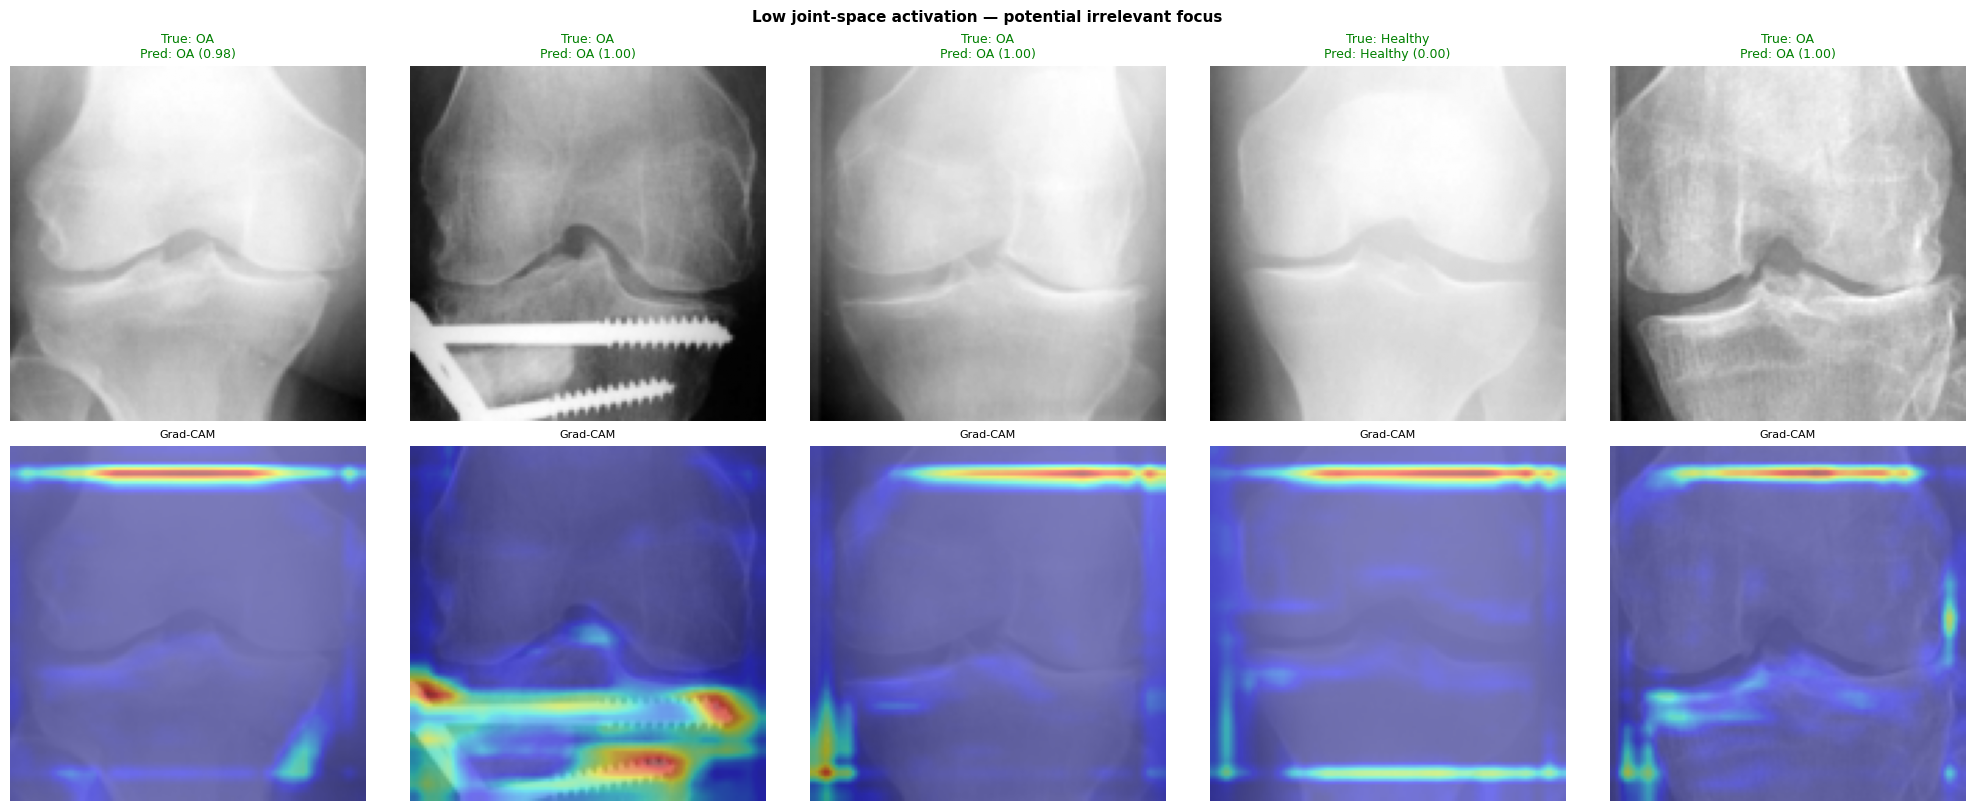

In [16]:
# Images where the model focuses LEAST on the joint space (possible irrelevant structures)
low_center_idx = np.argsort(center_frac_arr)[:6]
print(
    "Central-band fractions for lowest-focus images:",
    center_frac_arr[low_center_idx].round(3),
)
show_gradcam(
    low_center_idx,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Low joint-space activation — potential irrelevant focus",
)

# 5. Limitations of Score-CAM

Score-CAM avoids the gradient-flow problems of GradCAM, but has its own limitations:

1. **Coarse spatial resolution.** Heatmaps are produced at the resolution of the target feature map (32×32) and bilinearly upsampled to 128×128. Fine-grained structures such as joint-space width or small osteophytes cannot be localised precisely.

2. **Slow.** Score-CAM runs one full forward pass per channel at the target layer. With 256 channels, that is 256 forward passes per image — roughly 100× slower than GradCAM. Running it over the full test set of 146 images takes several minutes on GPU.

3. **Channel independence assumption.** Score-CAM weights each channel independently, ignoring interactions between channels. If the model's decision relies on joint patterns across multiple feature maps, Score-CAM may miss or misattribute them.

4. **No counterfactual grounding.** Like all CAM methods, Score-CAM shows where the model is *sensitive*, not what it would predict if that region were masked. The highlighted region could encode a proxy feature rather than the intended diagnostic signal.

5. **Confirmation-bias risk.** A heatmap that covers the joint space may look clinically convincing even when the underlying model uses spurious correlations. The quantitative spatial statistics (central-band fraction, CoM) provide a guard against purely visual over-interpretation.